# Customer Churn Prediction Model for a Coffee Delivery Service


**Date:** 2026-08-10  
**Author:** Andrey Kurmyshkin

## Project Plan

1. Load and perform an initial analysis of the data.
2. Conduct exploratory data analysis (EDA).
3. Preprocess the data and prepare the features.
4. Build a baseline model.
5. Create and select new features.
6. Tune hyperparameters and the classification threshold.
7. Train and evaluate the final model.
8. Prepare the final project report.
9. Save the model and verify that the artifact loads correctly.

## Stage 1. Environment and Library Setup

### [GitHub repository containing `requirements.txt`.](https://github.com/andreiyopt/coffee_churn_model)

In [1]:
# suppress only expected FutureWarning messages from sklearn
import warnings

warnings.filterwarnings(
    'ignore',
    category=FutureWarning,
    module='sklearn'
)

In [2]:
# import the libraries required for the project

import pandas as pd                                     # dataframes and data processing
import numpy as np                                      # array operations 

import matplotlib.pyplot as plt                         # visualization
import seaborn as sns                                   # heatmaps

from sklearn.model_selection import train_test_split    # data splitting
from sklearn.model_selection import cross_validate      # cross-validation
from sklearn.model_selection import  StratifiedKFold
from sklearn.model_selection import cross_val_predict 

from sklearn.compose import ColumnTransformer           # create transformers
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline                   # create pipeline
from sklearn.impute import SimpleImputer                # value imputation
from sklearn.preprocessing import OneHotEncoder         # scaling
from sklearn.preprocessing import StandardScaler        # scaling

                                                        # machine-learning models
from sklearn.linear_model import LogisticRegression     # logistic regression           
from sklearn.dummy import DummyClassifier               # dummy model

from sklearn.metrics import accuracy_score              # model-quality metrics
from sklearn.metrics import roc_auc_score
from sklearn.metrics import make_scorer
from sklearn.metrics import precision_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss

from sklearn.feature_selection import SelectFromModel   # select the best model variants 
from sklearn.model_selection import GridSearchCV

import joblib                                           # save the model

In [3]:
# set the random state
RANDOM_STATE = 42

In [4]:
# load the dataframe
# for convenient local work, the dataset is stored in the project folder, so the path starts with '../'; however, in 
# the final version the path will be changed to '/'
try: 
    data = pd.read_csv('../datasets/coffee_churn_dataset.csv', sep=',', decimal='.')   
except:  
    data = pd.read_csv('/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')
    
df_churn = pd.DataFrame(data)

# verify loading
display(df_churn.head(5))
print('Dataframe succesfully loaded!')

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


Dataframe succesfully loaded!


## Stage 2. Initial Data Analysis

### 1. Brief Data Overview

In [5]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

At first glance, the data does not contain many missing values. There are 17 numerical features and 10 categorical features.

In [6]:
display(df_churn.describe())

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


In [7]:
display(df_churn.describe(include='object'))

,user_id,last_coffee_type,preferred_roast,milk_preference,coffee_bean_origin,last_drink_size,subscription_status,seasons,phone_type,geo_location
count,10450,10192,10334,9782,9768,9946,9512,9771,10114,10340
unique,10450,3,3,6,6,3,4,4,3,100
top,user_01648,arabica,medium,whole,ethiopia,medium,none,spring,android,geo_2
freq,1,6134,3458,2876,1690,4925,3803,2507,4611,1629


- Outliers are apparent even before a detailed analysis.  
  
- The target variable `churn` has a noticeable class imbalance.
  
- Some fields contain negative values where they should not be possible.

In [8]:
# check negative values:
negative_counts = (df_churn.select_dtypes(include='number') < 0).sum()
negative_counts[negative_counts > 0].sort_values(ascending=False)

total_spent_last_week     171
order_frequency_week       83
review_rating_last_1        6
avg_order_value             2
median_order_value          2
total_spent_last_month      2
dtype: int64

Negative values are impossible in these columns. They should be replaced with `NaN` and imputed with the median after splitting the data.

#### Brief Data Overview — Conclusion

The dataset contains 10,450 observations and 27 columns: 17 numerical and 10 categorical. It includes missing values, outliers, and physically impossible negative values, while the target variable `churn` has a pronounced class imbalance.

### 2. Feature Descriptions


It is necessary to determine which features may be useful to the model and which can be removed.

1. `user_id` should be excluded because it is a unique identifier rather than a meaningful feature. The model could memorize individual users but would not be able to use this information for new customers.

2. `days_since_last_order` should be excluded only if the target variable `churn` was derived from it. If churn means that no orders were placed for a specified number of days, the model would receive the same information used to define the target class. This would cause target leakage and inflate the estimated model quality.

3. Monthly and weekly order frequency are likely to be strongly correlated. To avoid multicollinearity, only monthly order frequency could be retained. This should be revisited after checking the training set.

4. The same may apply to average and median order value. Their correlation should be checked on the training set.

5. The same principle applies to total spending per month and total spending per week.

6. `discount_usage_rate` may be associated with user loyalty, so it should be retained.

7. `last_coffee_type`, `preferred_roast`, `milk_preference`, and `coffee_bean_origin` are unlikely to have a strong relationship with loyalty, or that relationship may be difficult to interpret. Their usefulness should be checked after splitting the data.

8. Whether the user tried the seasonal menu may be related to loyalty, so this feature should be retained.

9. The size of the last order may contain useful information about user behavior.

10. Subscription information may be important for predicting churn.

11. App opens and enabled notifications may reflect user activity and be useful to the model.

12. The user's average rating may contain more information than the latest rating. These features may be multicollinear, so the question should be revisited after analyzing the training set.

13. Phone type is probably only indirectly related to the target. For example, users of different devices may have different purchasing behavior. It may nevertheless be unnecessary, so it should be retained for now and checked after the split.

14. Changes in taste preferences (`1/0`) may theoretically contain useful information about user behavior.

15. Geolocation should also be retained because a user's region may be related to churn probability.

In [9]:
# compare the distribution of days_since_last_order across classes
df_churn.groupby('churn')['days_since_last_order'].agg(
    ['min', 'max', 'median', 'mean']
)

,min,max,median,mean
churn,,,,
0,0.0,40.0,3.0,4.407880
1,0.0,33.0,3.0,4.180385


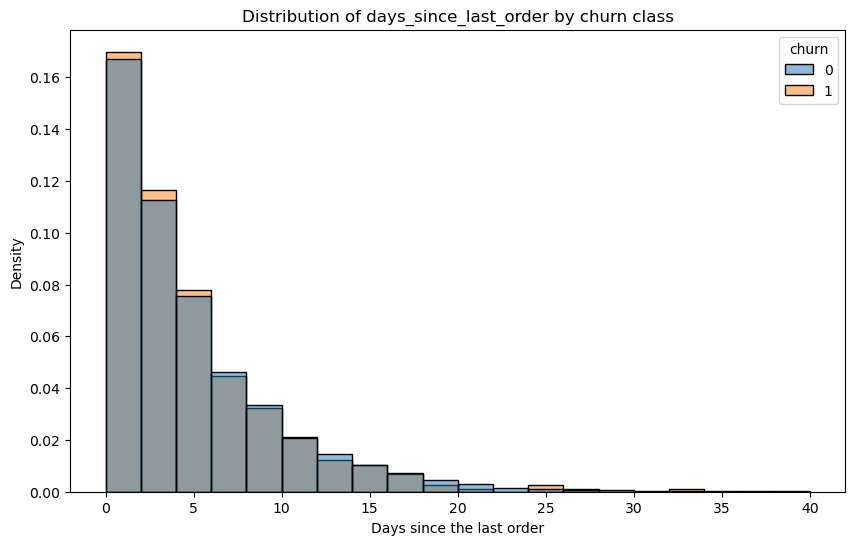

In [10]:
# compare the distribution of days_since_last_order across classes
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_churn,
    x='days_since_last_order',
    hue='churn',
    bins=20,
    stat='density',
    common_norm=False,
    alpha=0.5
)

plt.title('Distribution of days_since_last_order by churn class')
plt.xlabel('Days since the last order')
plt.ylabel('Density')
plt.show()

This feature alone would barely allow the model to distinguish customers who left from those who stayed. `days_since_last_order` has almost the same distribution for churned and retained customers.

#### Feature Descriptions — Conclusion

The unique identifier `user_id` should be removed because it contains no useful information for predicting new customers. The other features are potentially useful, although some pairs may duplicate information. `days_since_last_order` should be excluded only if it is confirmed that `churn` was derived from it.

### 3. Categorical Features

In [11]:
display(df_churn.describe(include='object'))

,user_id,last_coffee_type,preferred_roast,milk_preference,coffee_bean_origin,last_drink_size,subscription_status,seasons,phone_type,geo_location
count,10450,10192,10334,9782,9768,9946,9512,9771,10114,10340
unique,10450,3,3,6,6,3,4,4,3,100
top,user_01648,arabica,medium,whole,ethiopia,medium,none,spring,android,geo_2
freq,1,6134,3458,2876,1690,4925,3803,2507,4611,1629


In [12]:
# inspect category values
categorical_columns = df_churn.select_dtypes(include='object').columns

for column in categorical_columns:
    print(f'\n{column}:')
    print(df_churn[column].unique())


user_id:
['user_00318' 'user_07234' 'user_04816' ... 'user_05390' 'user_00860'
 'user_07270']

last_coffee_type:
['blend' 'arabica' 'robusta' nan]

preferred_roast:
['light' 'medium' 'dark' nan]

milk_preference:
['almond' 'whole' 'oat' 'skim' 'soy' nan 'none']

coffee_bean_origin:
['vietnam' 'guatemala' 'brazil' 'colombia' 'kenya' nan 'ethiopia']

last_drink_size:
['large' 'medium' 'small' nan]

subscription_status:
['pro' 'none' 'premium' 'basic' nan]

seasons:
['summer' 'autumn' 'spring' 'winter' nan]

phone_type:
['android' 'ios' 'web' nan]

geo_location:
['geo_75' 'geo_95' 'geo_25' 'geo_2' 'geo_19' 'geo_68' 'geo_3' 'geo_45'
 'geo_15' nan 'geo_30' 'geo_93' 'geo_64' 'geo_40' 'geo_87' 'geo_17'
 'geo_11' 'geo_94' 'geo_1' 'geo_50' 'geo_67' 'geo_51' 'geo_97' 'geo_16'
 'geo_78' 'geo_100' 'geo_98' 'geo_43' 'geo_8' 'geo_48' 'geo_61' 'geo_74'
 'geo_35' 'geo_59' 'geo_46' 'geo_5' 'geo_23' 'geo_91' 'geo_42' 'geo_90'
 'geo_4' 'geo_96' 'geo_57' 'geo_71' 'geo_54' 'geo_65' 'geo_32' 'geo_14'
 'geo

One-Hot Encoding is used for categorical features, including `geo_location`. The effect of `geo_location` will also be tested experimentally.

In [13]:
# also inspect binary categories
binary_columns = [
    column for column in df_churn.columns
    if df_churn[column].dropna().nunique() == 2
]

for column in binary_columns:
    print(f'\n{column}:')
    print(df_churn[column].value_counts(dropna=False))


seasonal_menu_tried:
1.0    6634
0.0    2827
NaN     989
Name: seasonal_menu_tried, dtype: int64

notifications_enabled:
1.0    7465
0.0    2448
NaN     537
Name: notifications_enabled, dtype: int64

coffee_preference_change:
0.0    7946
1.0    1894
NaN     610
Name: coffee_preference_change, dtype: int64

churn:
0    9821
1     629
Name: churn, dtype: int64


The classes are distributed unevenly, which should be considered when building the model.

#### Categorical Features — Conclusion

Categorical features with few values can be processed with One-Hot Encoding. For `geo_location`, which contains about 100 categories, Target Encoding performed strictly inside cross-validation may be considered. Binary features already represented as 0/1 require no additional encoding.

### 4. Handling Missing Values

In [14]:
# check the share of missing values in each column
(df_churn.isna().mean() * 100).sort_values(ascending=False)

seasonal_menu_tried         9.464115
days_since_last_order       9.043062
total_spent_last_week       9.033493
subscription_status         8.976077
app_opens_per_week          8.574163
review_rating_last_1        8.200957
median_order_value          7.952153
days_since_last_promo       6.995215
app_crashes_last_month      6.899522
review_rating_last_10       6.631579
coffee_bean_origin          6.526316
seasons                     6.497608
milk_preference             6.392344
coffee_preference_change    5.837321
order_frequency_month       5.741627
avg_order_value             5.578947
notifications_enabled       5.138756
last_drink_size             4.822967
discount_usage_rate         3.799043
order_frequency_week        3.712919
phone_type                  3.215311
total_spent_last_month      2.813397
last_coffee_type            2.468900
preferred_roast             1.110048
geo_location                1.052632
user_id                     0.000000
churn                       0.000000
d

* `churn` has no missing values.
  
* Continuous numerical features will be imputed with the `median`.

* Binary 0/1 features will be imputed with `most_frequent` to avoid creating the artificial value 0.5.

* Categorical text features will be imputed with `most_frequent`.

In [15]:
# check whether missing values are random or explainable
df_churn[df_churn['days_since_last_order']==0]

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
5,user_01247,0.0,1.284824,0.418197,1092.164843,338.082043,471.825472,159.366225,0.350490,arabica,...,0.0,4.235214,4.835587,1.0,winter,17.0,android,0.0,geo_68,0
9,user_01536,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,...,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0
18,user_04393,0.0,5.236275,1.132846,2288.324775,801.929704,NaN,1000.598857,0.296605,arabica,...,0.0,4.415193,3.125482,0.0,winter,15.0,android,0.0,geo_2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10423,user_02747,0.0,3.109886,0.778299,1425.781082,500.314428,1655.038396,320.956247,0.502604,robusta,...,0.0,4.679483,5.461553,1.0,winter,1.0,android,0.0,geo_3,0
10425,user_07849,0.0,5.715180,1.322105,NaN,262.177589,1607.098459,394.697651,0.253532,arabica,...,1.0,2.932678,4.654892,1.0,spring,2.0,android,1.0,geo_36,0
10426,user_02558,0.0,3.623658,0.868063,1505.014884,588.101217,2338.612811,656.103566,0.402130,arabica,...,NaN,3.531941,5.070048,1.0,spring,NaN,ios,0.0,geo_15,0
10437,user_06949,0.0,8.249873,1.919361,1488.591551,520.805292,3537.475567,946.806456,0.226926,arabica,...,1.0,4.452741,3.512895,0.0,spring,9.0,ios,0.0,geo_52,0


In [16]:
df_churn[df_churn['total_spent_last_week'].isna()]   

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
17,user_02085,3.0,3.503378,0.936460,1001.051602,405.030466,1584.914584,NaN,0.435147,arabica,...,1.0,5.683203,5.187074,0.0,winter,NaN,ios,0.0,geo_3,0
21,user_03457,5.0,4.289869,NaN,2678.323579,1459.123886,6913.253220,NaN,0.168081,robusta,...,1.0,2.502726,3.759893,1.0,winter,46.0,ios,NaN,geo_94,0
43,user_07539,2.0,1.379313,0.289451,1235.152935,NaN,947.938062,NaN,0.438557,robusta,...,1.0,3.006368,NaN,1.0,winter,33.0,android,0.0,geo_100,0
57,user_04771,2.0,5.445011,1.373850,765.754316,299.811228,1885.775446,NaN,0.465748,robusta,...,1.0,4.964828,3.794571,0.0,autumn,32.0,ios,0.0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10364,user_08571,NaN,2.850030,0.819650,386.270390,264.542002,814.544327,NaN,0.217156,arabica,...,1.0,3.758997,4.575189,1.0,autumn,3.0,android,0.0,geo_1,0
10374,user_06439,3.0,5.285265,1.273538,359.379477,257.865432,1252.671281,NaN,0.261663,blend,...,1.0,4.264202,4.017560,2.0,winter,22.0,NaN,0.0,geo_94,0
10385,user_09692,2.0,2.210407,0.471831,NaN,88.580720,167.262313,NaN,0.043340,robusta,...,1.0,4.282491,5.184235,0.0,winter,3.0,ios,0.0,geo_1,0
10433,user_06420,NaN,1.264390,0.593075,1062.297173,479.943650,536.683438,NaN,0.336729,blend,...,1.0,4.626942,3.307180,0.0,winter,27.0,ios,0.0,geo_52,0


Missingness is most likely random, so **after** splitting the data, missing values will be imputed with medians calculated **only** from the training set.

#### Explanation

One might assume that `NaN` in `total_spent_last_week` represents zero, but the last order may have been placed less than a week ago, so zero weekly spending would not be correct. Missing categorical values could represent zero-like categories, but the category inspection above shows an explicit `none` value, for example for subscriptions. The `NaN` values are therefore most likely random omissions.

#### Handling Missing Values — Conclusion

The missing-value share in any individual column does not exceed about 10%, but 78.19% of rows contain at least one missing value, so deleting those observations would cause substantial data loss. Numerical features will be imputed with the median, while binary and categorical features will be imputed with the most frequent value, calculated only from the training set inside the pipeline.

### 5. Duplicates

In [17]:
df_churn.duplicated().sum()

0

No explicit duplicates are present. Based on the category names examined, there appear to be no implicit duplicates either.

### 6. Possible Feature-Engineering Strategies


Several additional features can be created from the available data:

1. **Average spending per order**

   The ratio of total spending to the number of orders:

   - `total_spent_last_month / order_frequency_month`
   - `total_spent_last_week / order_frequency_week`

   This may represent customer value more accurately than spending and order count separately.

2. **Change in order frequency**

   Current weekly order frequency can be compared with average weekly frequency derived from monthly data:

   - `order_frequency_week - order_frequency_month / 4`

   A negative value may indicate declining user activity.

3. **Change in spending**

   Similarly, spending in the last week can be compared with average weekly spending for the month:

   - `total_spent_last_week - total_spent_last_month / 4`

   Lower spending may indicate potential churn.

4. **Deviation of the latest rating from the average**

   - `review_rating_last_1 - review_rating_last_10`

   This feature shows whether the user's latest experience was better or worse than usual.

5. **Discount-use intensity**

   `discount_usage_rate` can be combined with order frequency or total spending. This may distinguish active regular customers from users who purchase mainly because of discounts.

6. **User activity**

   A combined activity indicator can be created from:

   - `app_opens_per_week`;
   - `order_frequency_week`;
   - `notifications_enabled`;
   - `seasonal_menu_tried`.

7. **App stability**

   Ratio of app crashes to app opens:

   - `app_crashes_last_month / (app_opens_per_week * 4)`

   A high crash rate may harm the user experience and continued use of the service.

8. **Recency of interaction with the service**

   The following can be combined:

   - `days_since_last_order`;
   - `days_since_last_promo`.

   These features may reflect declining activity and interest.

9. **Interaction between subscription and activity**

   Combinations of `subscription_status` with order frequency, spending, and app opens can be tested. For example, low activity by a user with a paid subscription may be an important churn signal.

When creating ratios, cases where the denominator is zero must be handled separately. The final usefulness of new features will be evaluated through cross-validation.

#### Feature Engineering — Conclusion

The source data can be used to create features describing changes in order frequency and spending, average spending per order, deviation of the latest rating from the average, discount-use intensity, and app-crash frequency. New features should be added incrementally and their usefulness evaluated through cross-validation.

### 7. Outliers

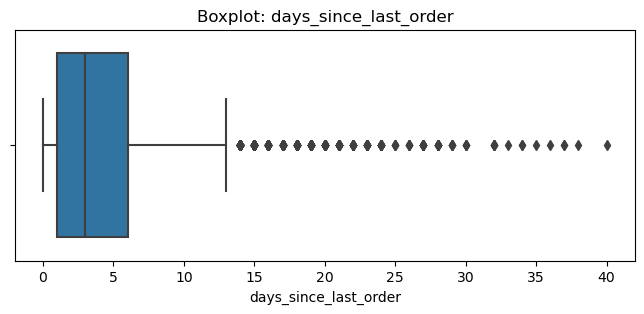

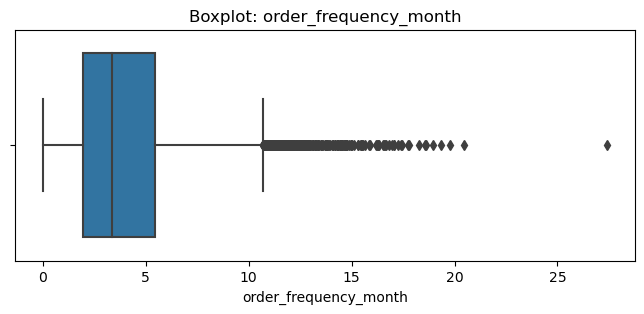

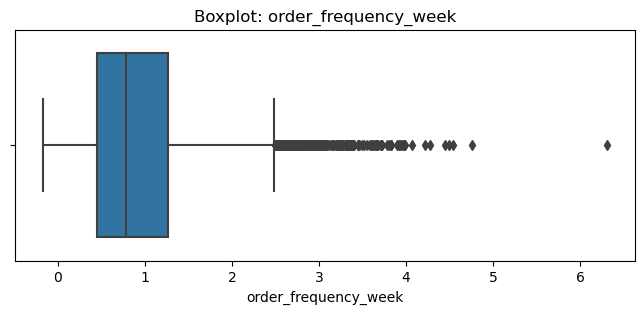

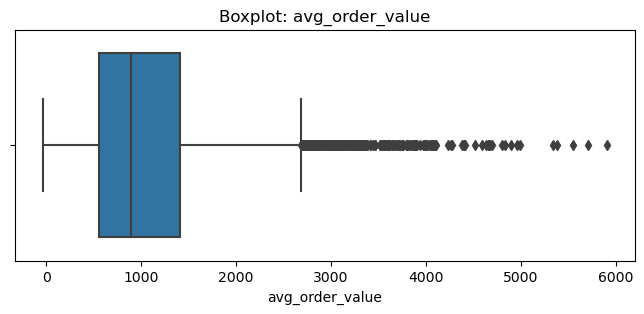

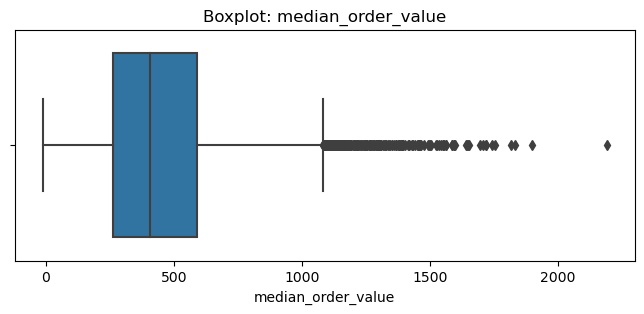

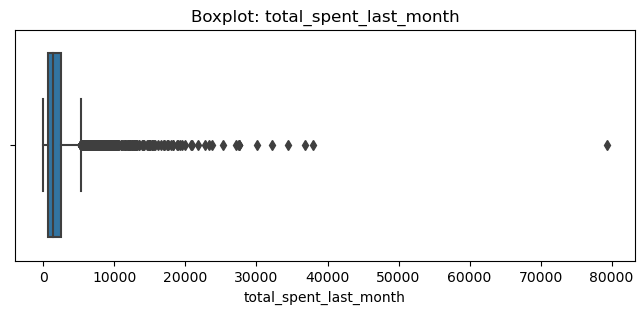

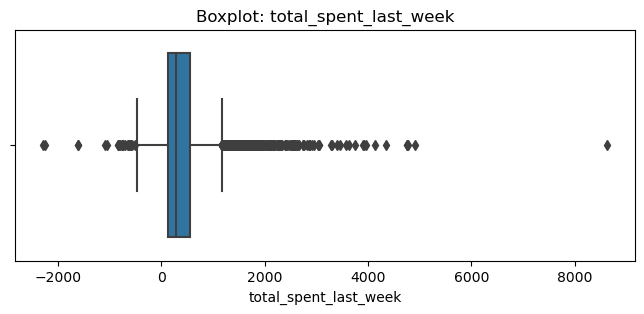

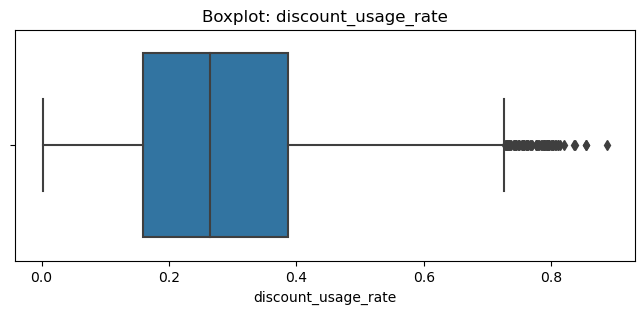

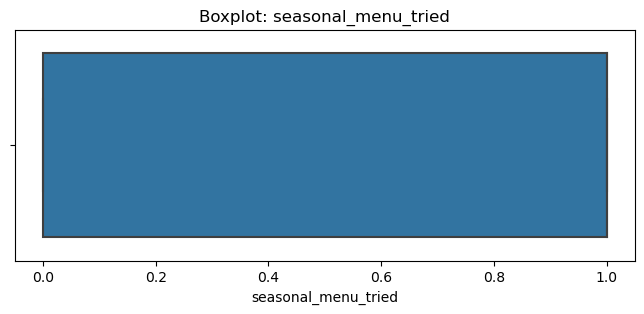

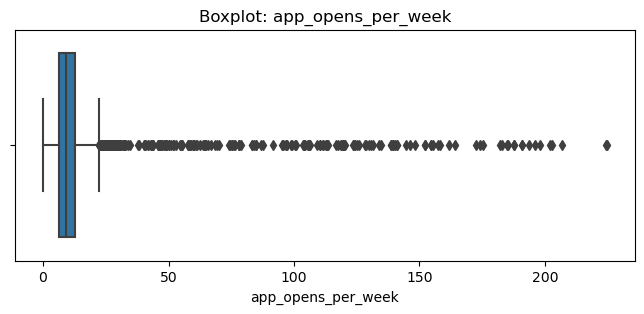

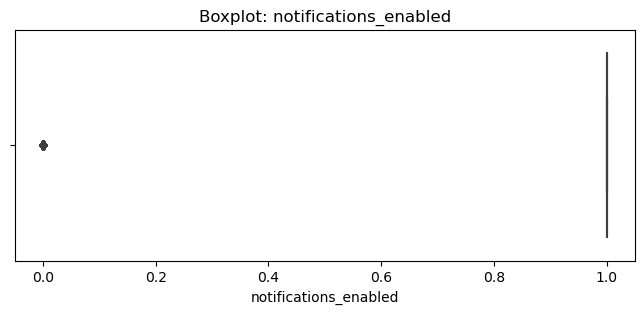

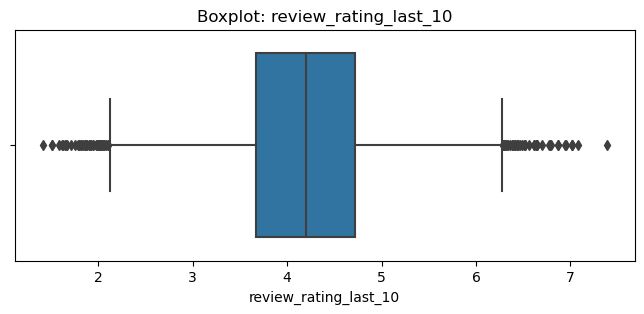

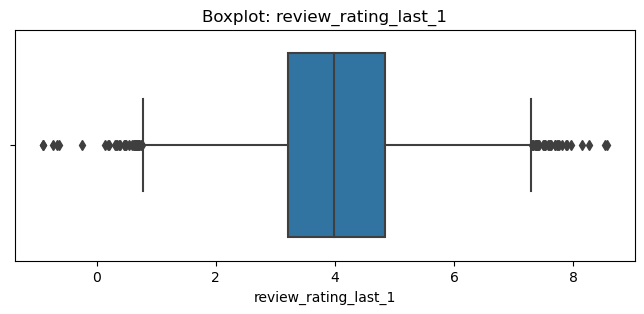

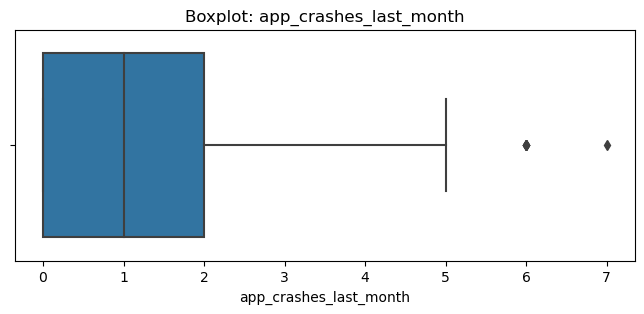

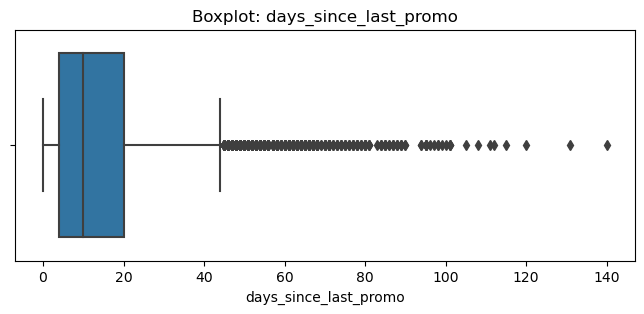

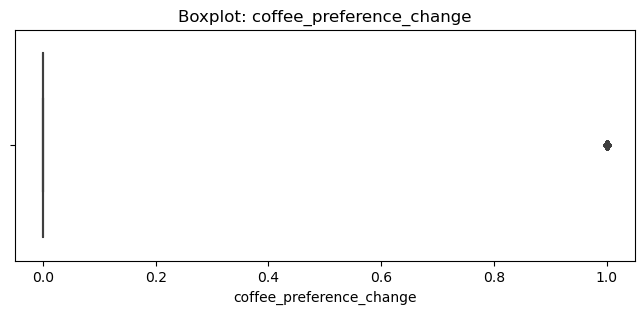

In [18]:
# visualize outliers separately for each numerical feature
numeric_columns = df_churn.select_dtypes(include='number').columns.drop('churn')

for column in numeric_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_churn[column])

    plt.title(f'Boxplot: {column}')
    plt.xlabel(column)

    plt.show()

Numerous prominent outliers appear in `avg_order_value`, `median_order_value`, `total_spent_last_month`, and `total_spent_last_week`. In every column except `total_spent_last_week`, these may be real values. Even monthly spending of 80,000 could be genuine, although it is probably an outlier. Negative weekly spending, however, is impossible, so these values must be handled after splitting the data.
  
A good approach is to apply `log1p` to `total_spent_last_month` and then standardize the data. The values are very large, and the difference between 30,000 and 40,000 is less meaningful than the difference between 1,000 and 10,000. Users spending 30,000–40,000 per month probably have similar incomes, while the incomes of users spending 1,000 and 10,000 are likely to differ substantially.

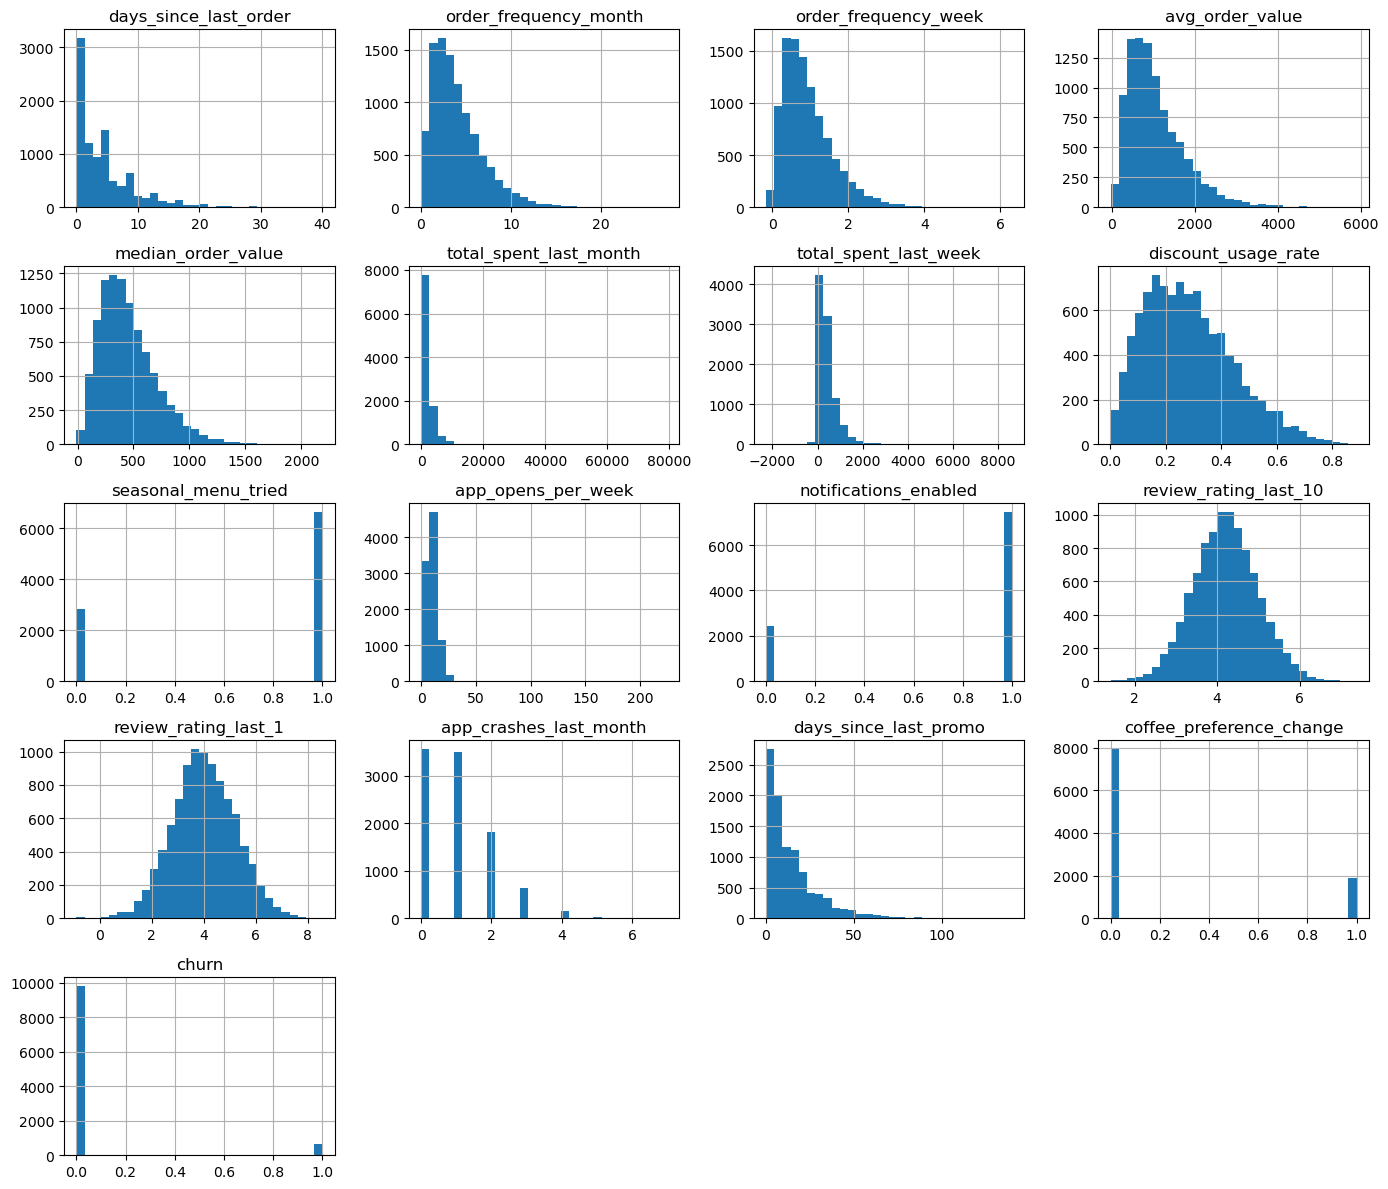

In [19]:
# also inspect the histograms
df_churn.hist(figsize=(14, 12), bins=30)
plt.tight_layout()
plt.show()

#### Outliers — Conclusion

Numerous outliers were found in monetary and count features, but most high values may represent real customer behavior and should not be removed automatically. Physically impossible negative values will be replaced with `NaN`, while heavily skewed monetary features will undergo a `log1p` transformation followed by scaling.

### 8. Feature Correlation Heatmap

In [20]:
# Spearman correlation for numerical features
corr_matrix = df_churn.corr(method='spearman')

corr_matrix['churn'].sort_values(ascending=False)

churn                       1.000000
app_crashes_last_month      0.366156
app_opens_per_week          0.126020
order_frequency_week        0.062504
order_frequency_month       0.060196
total_spent_last_week       0.043538
total_spent_last_month      0.040341
review_rating_last_1        0.015638
days_since_last_promo       0.014753
coffee_preference_change   -0.000194
median_order_value         -0.001105
notifications_enabled      -0.003758
seasonal_menu_tried        -0.006234
days_since_last_order      -0.008290
discount_usage_rate        -0.009789
review_rating_last_10      -0.011572
avg_order_value            -0.015031
Name: churn, dtype: float64

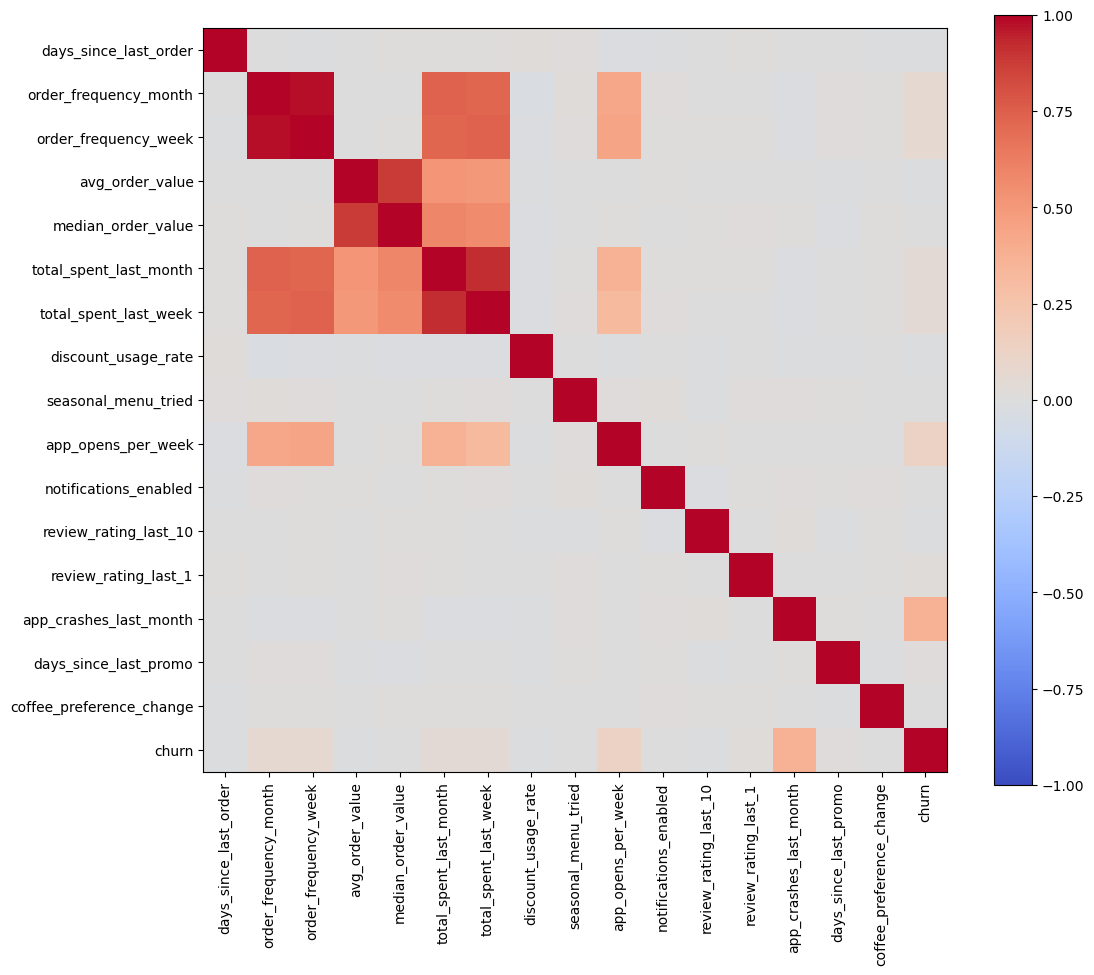

In [21]:
plt.figure(figsize=(12, 10))

plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.show()

Spearman correlation is used for numerical features because it detects monotonic as well as linear relationships and is less sensitive to outliers. Categorical features are not included in this correlation analysis, so `phik` is not used here.

The heatmap shows several strongly positively correlated pairs:

- `order_frequency_month` and `order_frequency_week`;
- `avg_order_value` and `median_order_value`;
- `total_spent_last_month` and `total_spent_last_week`.

To reduce multicollinearity, the preliminary decision is to:

- retain `order_frequency_month` and remove `order_frequency_week`;
- retain `avg_order_value` and remove `median_order_value`;
- retain `total_spent_last_month` and remove `total_spent_last_week`.

Monthly measures were chosen because they are more stable and less sensitive to random changes during a single week. The remaining numerical features do not show such strong mutual correlation and are retained for now.

`app_crashes_last_month` is noticeably correlated with `churn`, but this is not multicollinearity. It should be retained because app crashes may be related to user churn.

The final feature-removal decision should be confirmed after splitting the data by calculating correlations on the training set only.

#### Feature Correlation — Conclusion

Strong positive correlation was found between monthly and weekly order-frequency and spending measures, as well as between average and median order value. To reduce multicollinearity, the preliminary decision is to retain monthly measures and `avg_order_value`; final selection will be performed after the split using only the training set.

### Overall EDA Conclusion

The exploratory analysis examined a dataset of 10,450 observations and 27 columns describing order history, spending, customer preferences, app use, subscriptions, and geographic region. The target is `churn`, indicating whether a customer stopped using the service.

The target contains no missing values, but the classes are imbalanced: about 94% of observations belong to class `0` and about 6% to class `1`. Stratification will therefore be required when splitting the data. Model evaluation should focus not only on accuracy but especially on imbalance-aware metrics such as PR-AUC and Log Loss.

Although no individual column has more than about 10% missing values, 78.19% of rows contain at least one. Deleting incomplete rows would remove most of the sample. Numerical features will be imputed with medians and binary and categorical features with their most frequent values. All imputation values must be learned only from the training data inside the pipeline to prevent leakage.

Several numerical features contain physically impossible negative values for counts, spending, or ratings. These values should be treated as data errors, replaced with `NaN`, and processed with the other missing values. This rule should also be part of the pipeline so it applies consistently to training, test, and new data.

No full duplicates were found. `user_id` is a unique identifier with no meaningful predictive information for new customers and should be excluded. `days_since_last_order` may be retained only if `churn` was not derived directly from it; otherwise it would create target leakage.

Most categorical features have few categories and can use One-Hot Encoding. `geo_location` has about 100 values, so One-Hot Encoding will substantially increase dimensionality. Target Encoding could be considered, but it must be fitted only on the training portion of each cross-validation fold. Binary 0/1 features need no additional encoding.

Numerical features contain outliers and pronounced right skew. High spending and order values may be genuine, so they should not be removed solely by boxplot bounds. Applying `log1p` and then scaling is appropriate for heavily skewed positive monetary features.

Correlation analysis found strong relationships between monthly and weekly order frequency, average and median order value, and monthly and weekly total spending. The preliminary choice is to retain the more stable monthly measures, remove weekly measures, and retain `avg_order_value`. The final decision should use only the training set. `app_crashes_last_month` has a noticeable relationship with `churn` and should remain as a potentially important predictor.

Possible engineered features include changes in weekly activity relative to the monthly average, changes in spending, average spending per order, deviation of the latest rating from the average, crash rate, subscription–activity interactions, and discount-use indicators. They should be added incrementally and evaluated with cross-validation.

Overall, the data is suitable for modeling after removing `user_id`, handling missing and invalid negative values, encoding categories, transforming heavily skewed features, and removing redundant correlated columns. Every transformation that depends on the data distribution or target must be fitted exclusively on the training data inside the pipeline.

## Stage 3. Data Preprocessing

### 1. Data Split

In [22]:
# split the data in an 80/20 ratio 
X = df_churn.drop(columns='churn')
y = df_churn['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    random_state=RANDOM_STATE, 
                                                    test_size=0.2,
                                                    stratify=y)

In [23]:
numeric_features = [                           # Numerical features
    'days_since_last_order',
    'order_frequency_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'app_crashes_last_month',
    'days_since_last_promo'
]

negative_features = [                          # Numerical features with invalid negative outliers
    'order_frequency_week',
    'avg_order_value',
    'median_order_value',
    'review_rating_last_1'
]

log_features = [                               # Numerical features with invalid negative outliers,
    'total_spent_last_month',                  # and large positive outliers
    'total_spent_last_week'
]

binary_features = [                            #  Binary features
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change'
]

categorical_features = [                       # Categorical features
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'seasons',
    'phone_type',
    'geo_location'
]

features_to_drop = [                           # features not needed for training
    'user_id'
]

### 2. Data Preprocessing

In [24]:
# create the preprocessor

# function that replaces invalid negative values with NaN
def replace_negative_with_nan(X):
    return np.where(X < 0, np.nan, X)


# transformer for handling negative values
negative_to_nan = FunctionTransformer(replace_negative_with_nan)

full_preprocessor = ColumnTransformer(transformers=[                        # complete preprocessing transformer
    ('cat',                                                                 # categorical features
    Pipeline(steps=[
                   ('imputer', SimpleImputer(strategy='most_frequent')),
                   ('encoder', OneHotEncoder(sparse=False))
    ]),
    categorical_features),
                                                    
    ('num',                                                                 # numerical features
    Pipeline(steps=[
                   ('imputer', SimpleImputer(strategy='median')),
                   ('scaler', StandardScaler())       
    ]),
    numeric_features),
    
    ('bin',                                                                 # binary features
    SimpleImputer(strategy='most_frequent'),
    binary_features),
    
    ('neg',                                                                 # features with negative outliers
     Pipeline(steps=[
                    ('negative_to_NuN', negative_to_nan),
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
    ]),
    negative_features),
    
    ('log',                                                                 # features with negative outliers and
    Pipeline(steps=[                                                        # very large positive outliers
                        ('negative_to_NuN', negative_to_nan),
                        ('imputer', SimpleImputer(strategy='median')),
                        ('log1',FunctionTransformer(np.log1p)),
                        ('scaler', StandardScaler())
    ]),
    log_features)
])

### Data Preprocessing Conclusions

Different preprocessing strategies were defined for different feature types. Missing values are imputed with the median or most frequent value, invalid negative values are converted to `NaN`, and strongly right-skewed features are additionally log-transformed. All operations are included in a `ColumnTransformer`, allowing preprocessing within the pipeline without data leakage.

## Stage 4. Model Training

### 1. Cross-Validation Setup

In [25]:
# set up cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### 2. Pipelines for the Dummy and Baseline Models

In [26]:
# prepare the baseline and logistic-regression models

dummy_model = DummyClassifier()
log_reg = LogisticRegression()

In [27]:
# prepare the pipelines

dummy_pipeline  = Pipeline(steps=[
                                 ('preprocessor', full_preprocessor),
                                 ('model', dummy_model)
])

logreg_pipeline = Pipeline(steps=[
                                 ('preprocessor', full_preprocessor),
                                 ('model', log_reg)
])

### Cross-Validation and Metric Output

In [28]:
# run baseline cross-validation
scoring = {
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'average_precision': 'average_precision',
    'log_loss': 'neg_log_loss'
}
dummy_results = cross_validate(
    estimator=dummy_pipeline,     # model or pipeline
    X=X_train,                    # features
    y=y_train,                    # target variable
    scoring=scoring,              # metric list
    cv=cv,                        # splitting strategy
    return_train_score = True,    # calculate training-set quality
    return_estimator = True,      # retain fitted model instances
    n_jobs=1                      # CPU cores used
)

In [29]:
# run logistic-regression cross-validation
logreg_pipeline.set_params(model__max_iter=1000)
logreg_results = cross_validate(
    estimator=logreg_pipeline,     # model or pipeline
    X=X_train,                    # features
    y=y_train,                    # target variable
    scoring=scoring,              # metric list
    cv=cv,                        # splitting strategy
    return_train_score = True,    # calculate training-set quality
    return_estimator = True,      # retain fitted model instances
    n_jobs=1                      # CPU cores used
)

In [30]:
results_table = pd.DataFrame({
    'metric': ['precision', 'recall', 'f1', 'average_precision', 'neg_log_loss'],

    'DummyClassifier': [
        dummy_results['test_precision'].mean(),
        dummy_results['test_recall'].mean(),
        dummy_results['test_f1'].mean(),
        dummy_results['test_average_precision'].mean(),
        -dummy_results['test_log_loss'].mean()

    ],

    'LogisticRegression': [
        logreg_results['test_precision'].mean(),
        logreg_results['test_recall'].mean(),
        logreg_results['test_f1'].mean(),
        logreg_results['test_average_precision'].mean(),
        -logreg_results['test_log_loss'].mean()
    ]
})

display(results_table)

,metric,DummyClassifier,LogisticRegression
0,precision,0.000000,0.739010
1,recall,0.000000,0.447327
2,f1,0.000000,0.552852
3,average_precision,0.060167,0.649477
4,neg_log_loss,0.227428,0.125011


### Conclusions

Logistic regression significantly outperforms `DummyClassifier`, showing that the model identifies patterns associated with customer churn. A `Precision` of about 0.74 means that most customers predicted to churn actually belong to class `churn = 1`.

However, a `Recall` of about 0.45 means that the model finds fewer than half of the customers who actually churn and misses a substantial share. An `F1` score of about 0.55 indicates that the balance between precision and recall is not yet ideal.

The high `PR-AUC` indicates that the model generally separates the classes well across classification thresholds. The next step is to test whether feature engineering, feature selection, and model tuning can improve performance.

## Stage 5. Creating New Features

In [31]:
# function that creates new features inside the pipeline
def add_new_features(X):
    
    X = X.copy()

    # 1. Change in order frequency
    X['order_frequency_change'] = (
        X['order_frequency_week'].mask(
            X['order_frequency_week'] < 0
        )
        - X['order_frequency_month'] / 4
    )

    # 2. Change in rating
    X['review_rating_change'] = (
        X['review_rating_last_1'].mask(
            X['review_rating_last_1'] < 0
        )
        - X['review_rating_last_10']
    )

    # 3. Squared crash count
    X['app_crashes_squared'] = (
        X['app_crashes_last_month'] ** 2
    )

    return X


# transformer that creates new features
feature_engineering = FunctionTransformer(add_new_features)

In [32]:
# new feature lists

numeric_features = [                           # Numerical features
    'days_since_last_order',
    'order_frequency_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'app_crashes_last_month',
    'days_since_last_promo',

    # New features
    'order_frequency_change',                  # change in order frequency
    'review_rating_change',                    # change in user rating
    'app_crashes_squared'                      # squared app-crash count
]


negative_features = [                          # Numerical features with invalid negative values
    'avg_order_value'
]


log_features = [                               # Numerical features with strong right skew
    'total_spent_last_month'
]


binary_features = [                            # Binary features
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change'
]


categorical_features = [                       # Categorical features
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'seasons',
    'phone_type',
    'geo_location'
]


features_to_drop = [                           # Features no longer used for training
    'user_id',
    'order_frequency_week',                    # replaced by month + order_frequency_change
    'median_order_value',                      # strongly correlated with avg_order_value
    'total_spent_last_week',                   # strongly correlated with total_spent_last_month
    'review_rating_last_1'                     # replaced by last_10 + review_rating_change
]

In [33]:
# create the preprocessor




new_full_preprocessor = ColumnTransformer(transformers=[                        # complete preprocessing transformer
    ('cat',                                                                 # categorical features
    Pipeline(steps=[
                   ('imputer', SimpleImputer(strategy='most_frequent')),
                   ('encoder', OneHotEncoder(sparse=False))
    ]),
    categorical_features),
                                                    
    ('num',                                                                 # numerical features
    Pipeline(steps=[
                   ('imputer', SimpleImputer(strategy='median')),
                   ('scaler', StandardScaler())       
    ]),
    numeric_features),
    
    ('bin',                                                                 # binary features
    SimpleImputer(strategy='most_frequent'),
    binary_features),
    
    ('neg',                                                                 # features with negative outliers
     Pipeline(steps=[
                    ('negative_to_NuN', negative_to_nan),
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
    ]),
    negative_features),
    
    ('log',                                                                 # features with negative outliers and
    Pipeline(steps=[                                                        # very large positive outliers
                        ('negative_to_NuN', negative_to_nan),
                        ('imputer', SimpleImputer(strategy='median')),
                        ('log1',FunctionTransformer(np.log1p)),
                        ('scaler', StandardScaler())
    ]),
    log_features)
])

In [34]:
# pipeline with feature engineering
new_logreg_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_engineering),
    ('preprocessor', new_full_preprocessor),
    ('model', log_reg)
])

In [35]:
# run logistic-regression cross-validation
new_logreg_pipeline.set_params(model__max_iter=1000)
new_logreg_results = cross_validate(
    estimator=new_logreg_pipeline,    # model or pipeline
    X=X_train,                  # features
    y=y_train,                    # target variable
    scoring=scoring,              # metric list
    cv=cv,                        # splitting strategy
    return_train_score = True,    # calculate training-set quality
    return_estimator = True,      # retain fitted model instances
    n_jobs=1                      # CPU cores used
)

In [36]:
new_results_table = pd.DataFrame({
    'metric': ['precision', 'recall', 'f1', 'average_precision', 'log_loss'],

    'DummyClassifier': [
        dummy_results['test_precision'].mean(),
        dummy_results['test_recall'].mean(),
        dummy_results['test_f1'].mean(),
        dummy_results['test_average_precision'].mean(),
        -dummy_results['test_log_loss'].mean()

    ],

    'LogisticRegression': [
        logreg_results['test_precision'].mean(),
        logreg_results['test_recall'].mean(),
        logreg_results['test_f1'].mean(),
        logreg_results['test_average_precision'].mean(),
        -logreg_results['test_log_loss'].mean()
    ],
    
    'LogisticRegression_new': [
    new_logreg_results['test_precision'].mean(),
    new_logreg_results['test_recall'].mean(),
    new_logreg_results['test_f1'].mean(),
    new_logreg_results['test_average_precision'].mean(),
    -new_logreg_results['test_log_loss'].mean()
    ]
})

display(new_results_table)

,metric,DummyClassifier,LogisticRegression,LogisticRegression_new
0,precision,0.000000,0.739010,0.746752
1,recall,0.000000,0.447327,0.463248
2,f1,0.000000,0.552852,0.568695
3,average_precision,0.060167,0.649477,0.660703
4,log_loss,0.227428,0.125011,0.121846


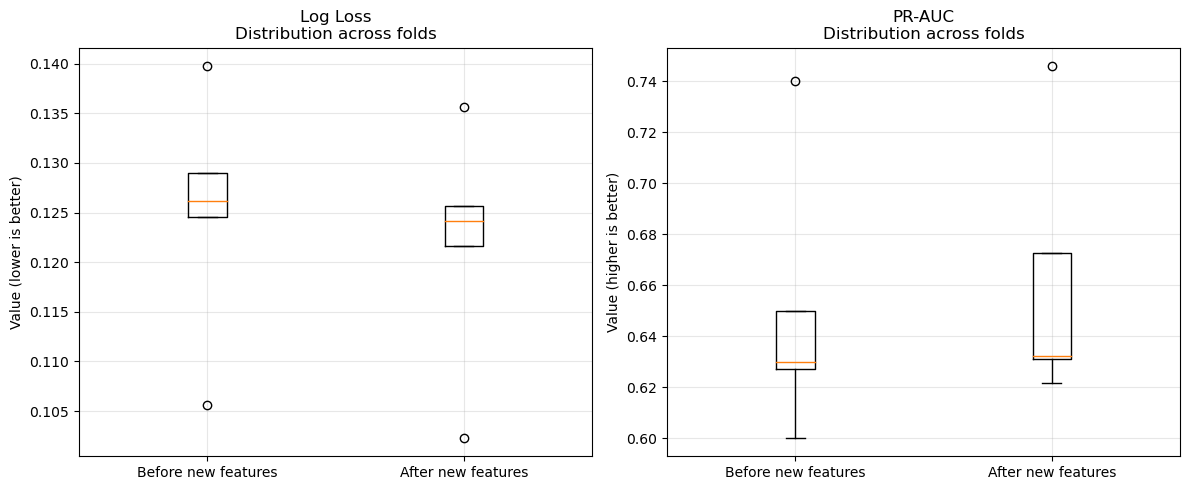

Model stability analysis:
-----------------------------------------------------------------
Metric       Model                  Mean       Std. dev.  CV%     
-----------------------------------------------------------------
LOG_LOSS     Before new features    0.125      0.011      8.8     
             After new features     0.122      0.011      8.9     

PR_AUC       Before new features    0.649      0.048      7.4     
             After new features     0.661      0.046      7.0     



In [37]:
# collect per-fold results for the old and new LogisticRegression models
# cross_validate stores Log Loss with a negative sign, so restore the usual sign
base_data = [
    -logreg_results['test_log_loss'],
    logreg_results['test_average_precision']
]

new_data = [
    -new_logreg_results['test_log_loss'],
    new_logreg_results['test_average_precision']
]

metrics_names = ['Log Loss', 'PR-AUC']


# visualize metric distributions across folds
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (metric_name, base_scores, new_scores) in enumerate(
    zip(metrics_names, base_data, new_data)
):
    
    # compare the old and new model versions
    box_data = [base_scores, new_scores]
    labels = ['Before new features', 'After new features']

    axes[i].boxplot(box_data, labels=labels)

    axes[i].set_title(f'{metric_name}\nDistribution across folds')
    axes[i].grid(True, alpha=0.3)

    # lower is better for Log Loss; higher is better for PR-AUC
    if metric_name == 'Log Loss':
        axes[i].set_ylabel('Value (lower is better)')
    else:
        axes[i].set_ylabel('Value (higher is better)')

plt.tight_layout()
plt.show()


# analyze result stability across folds
print("Model stability analysis:")
print("-" * 65)
print(f"{'Metric':<12} {'Model':<22} {'Mean':<10} {'Std. dev.':<10} {'CV%':<8}")
print("-" * 65)

for i, metric in enumerate(['log_loss', 'pr_auc']):

    # Old LogisticRegression
    base_scores = base_data[i]
    base_mean = np.mean(base_scores)
    base_std = np.std(base_scores)
    base_cv = (base_std / base_mean) * 100

    print(
        f"{metric.upper():<12} "
        f"{'Before new features':<22} "
        f"{base_mean:<10.3f} "
        f"{base_std:<10.3f} "
        f"{base_cv:<8.1f}"
    )

    # LogisticRegression after feature changes
    new_scores = new_data[i]
    new_mean = np.mean(new_scores)
    new_std = np.std(new_scores)
    new_cv = (new_std / new_mean) * 100

    print(
        f"{'':<12} "
        f"{'After new features':<22} "
        f"{new_mean:<10.3f} "
        f"{new_std:<10.3f} "
        f"{new_cv:<8.1f}"
    )
    
    print()

In [38]:
# train the current improved model on the full training set
new_logreg_pipeline.fit(X_train, y_train)

# retrieve the fitted pipeline components
fitted_preprocessor = new_logreg_pipeline.named_steps['preprocessor']
fitted_model = new_logreg_pipeline.named_steps['model']

In [39]:
# categorical feature names after One-Hot Encoding
cat_names = (
    fitted_preprocessor
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names(categorical_features)
)

# collect all feature names in the same order,
# in which they are output by ColumnTransformer
feature_names = np.concatenate([
    cat_names,
    numeric_features,
    binary_features,
    negative_features,
    log_features
])

# create the coefficient table
coef_table = pd.DataFrame({
    'feature': feature_names,
    'coefficient': fitted_model.coef_[0]
})

# the coefficient magnitude represents effect strength
coef_table['abs_coefficient'] = coef_table['coefficient'].abs()

coef_table = coef_table.sort_values(
    'abs_coefficient',
    ascending=False
)

display(coef_table.head(30))

,feature,coefficient,abs_coefficient
141,app_crashes_squared,1.527059,1.527059
104,geo_location_geo_74,1.435555,1.435555
35,geo_location_geo_11,1.069476,1.069476
130,geo_location_geo_98,-1.066503,1.066503
53,geo_location_geo_28,1.021565,1.021565
97,geo_location_geo_68,0.932139,0.932139
125,geo_location_geo_93,0.913551,0.913551
84,geo_location_geo_56,0.855584,0.855584
24,subscription_status_pro,0.854959,0.854959
59,geo_location_geo_33,0.847545,0.847545


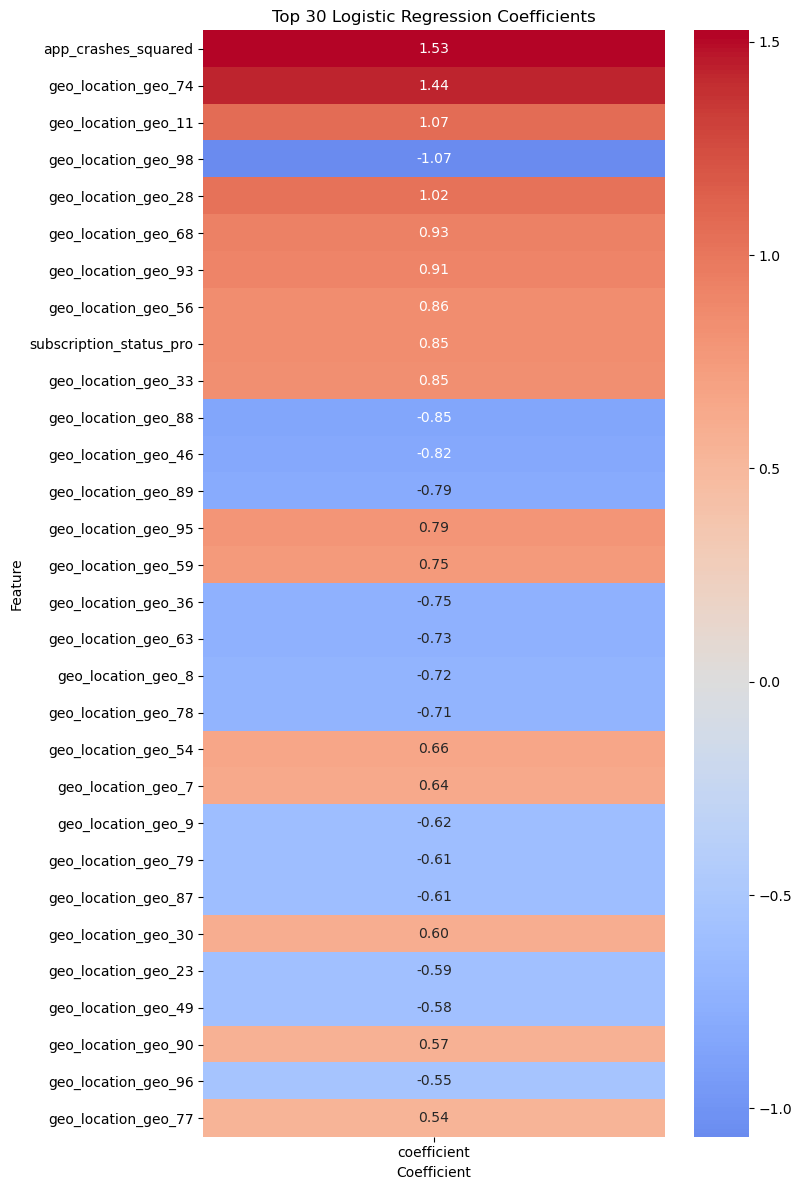

In [40]:
# select the 30 strongest coefficients
top_coef = (
    coef_table
    .nlargest(30, 'abs_coefficient')
    .set_index('feature')[['coefficient']]
)

# plot the coefficient heatmap
plt.figure(figsize=(8, 12))

sns.heatmap(
    top_coef,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f'
)

plt.title('Top 30 Logistic Regression Coefficients')
plt.ylabel('Feature')
plt.xlabel('Coefficient')

plt.tight_layout()
plt.show()

#### Experimental Model Without Location

In [41]:
# EXPERIMENTAL MODEL WITHOUT GEO_LOCATION

# new feature lists

numeric_features = [                           # Numerical features
    'days_since_last_order',
    'order_frequency_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'app_crashes_last_month',
    'days_since_last_promo',

    # New features
    'order_frequency_change',                  # change in order frequency
    'review_rating_change',                    # change in user rating
    'app_crashes_squared'                      # squared app-crash count
]


negative_features = [                          # Numerical features with invalid negative values
    'avg_order_value'
]


log_features = [                               # Numerical features with strong right skew
    'total_spent_last_month'
]


binary_features = [                            # Binary features
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change'
]


categorical_features = [                       # Categorical features
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'seasons',
    'phone_type'
]


features_to_drop = [                           # Features no longer used for training
    'user_id',
    'order_frequency_week',                    # replaced by month + order_frequency_change
    'median_order_value',                      # strongly correlated with avg_order_value
    'total_spent_last_week',                   # strongly correlated with total_spent_last_month
    'review_rating_last_1'                     # replaced by last_10 + review_rating_change
]


# create the preprocessor






exp_full_preprocessor = ColumnTransformer(transformers=[                        # complete preprocessing transformer
    ('cat',                                                                 # categorical features
    Pipeline(steps=[
                   ('imputer', SimpleImputer(strategy='most_frequent')),
                   ('encoder', OneHotEncoder(sparse=False))
    ]),
    categorical_features),
                                                    
    ('num',                                                                 # numerical features
    Pipeline(steps=[
                   ('imputer', SimpleImputer(strategy='median')),
                   ('scaler', StandardScaler())       
    ]),
    numeric_features),
    
    ('bin',                                                                 # binary features
    SimpleImputer(strategy='most_frequent'),
    binary_features),
    
    ('neg',                                                                 # features with negative outliers
     Pipeline(steps=[
                    ('negative_to_NuN', negative_to_nan),
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
    ]),
    negative_features),
    
    ('log',                                                                 # features with negative outliers and
    Pipeline(steps=[                                                        # very large positive outliers
                        ('negative_to_NuN', negative_to_nan),
                        ('imputer', SimpleImputer(strategy='median')),
                        ('log1',FunctionTransformer(np.log1p)),
                        ('scaler', StandardScaler())
    ]),
    log_features)
])


# experimental pipeline without geo_location
exp_logreg_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_engineering),  # create new features
    ('preprocessor', exp_full_preprocessor),
    ('model', log_reg)
])

# run logistic-regression cross-validation

exp_logreg_results = cross_validate(
    estimator=exp_logreg_pipeline,    # model or pipeline
    X=X_train,                    # features
    y=y_train,                    # target variable
    scoring=scoring,              # metric list
    cv=cv,                        # splitting strategy
    return_train_score = True,    # calculate training-set quality
    return_estimator = True,      # retain fitted model instances
    n_jobs=1                      # CPU cores used
)

In [42]:
new_results_table = pd.DataFrame({
    'metric': ['precision', 'recall', 'f1', 'average_precision', 'log_loss'],

    'DummyClassifier': [
        dummy_results['test_precision'].mean(),
        dummy_results['test_recall'].mean(),
        dummy_results['test_f1'].mean(),
        dummy_results['test_average_precision'].mean(),
        -dummy_results['test_log_loss'].mean()

    ],

    'LogisticRegression': [
        logreg_results['test_precision'].mean(),
        logreg_results['test_recall'].mean(),
        logreg_results['test_f1'].mean(),
        logreg_results['test_average_precision'].mean(),
        -logreg_results['test_log_loss'].mean()
    ],
    
    'LogisticRegression_new': [
    new_logreg_results['test_precision'].mean(),
    new_logreg_results['test_recall'].mean(),
    new_logreg_results['test_f1'].mean(),
    new_logreg_results['test_average_precision'].mean(),
    -new_logreg_results['test_log_loss'].mean()
    ],
    
    'LogisticRegression_exp': [
        exp_logreg_results['test_precision'].mean(),
        exp_logreg_results['test_recall'].mean(),
        exp_logreg_results['test_f1'].mean(),
        exp_logreg_results['test_average_precision'].mean(),
        -exp_logreg_results['test_log_loss'].mean()
        ]
})

display(new_results_table)

,metric,DummyClassifier,LogisticRegression,LogisticRegression_new,LogisticRegression_exp
0,precision,0.000000,0.739010,0.746752,0.748333
1,recall,0.000000,0.447327,0.463248,0.439406
2,f1,0.000000,0.552852,0.568695,0.549824
3,average_precision,0.060167,0.649477,0.660703,0.672473
4,log_loss,0.227428,0.125011,0.121846,0.118883


- Without `geo_location`, PR-AUC increased from 0.661 to 0.672 and Log Loss improved from 0.122 to 0.119, so the model ranks customers and estimates probabilities slightly better without geography.
  
- However, Recall fell from 0.463 to 0.439 and F1 from 0.569 to 0.550. At the standard 0.5 threshold, the model therefore missed more churned customers.
  
- Precision was almost unchanged.
  
The results are mixed, so `geo_location` will be retained for now.

### 4. Selecting the Best Threshold for Feature Removal

In [43]:
# store the results for each threshold here
threshold_results = []

# test several threshold values
for threshold in [0.01, 0.03, 0.05, 0.1]:

    # within each CV fold, LogisticRegression determines
    # coefficients and removes features weaker than the specified threshold
    selector = SelectFromModel(
        estimator=LogisticRegression(max_iter=1000),
        threshold=threshold
    )

    # preprocessing -> feature selection -> final model
    pipeline = Pipeline(steps=[
        ('preprocessor', full_preprocessor),
        ('selector', selector),
        ('model', LogisticRegression(max_iter=1000))
    ])

    # evaluate this threshold with cross-validation
    results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=1
    )

    # store the mean results
    threshold_results.append({
        'threshold': threshold,
        'precision': results['test_precision'].mean(),
        'recall': results['test_recall'].mean(),
        'f1': results['test_f1'].mean(),
        'pr_auc': results['test_average_precision'].mean(),
        'log_loss': -results['test_log_loss'].mean()
    })
    
    # compare all thresholds
threshold_table = pd.DataFrame(threshold_results)

display(threshold_table)

,threshold,precision,recall,f1,pr_auc,log_loss
0,0.01,0.739010,0.447327,0.552852,0.649136,0.125013
1,0.03,0.740910,0.451327,0.556344,0.649307,0.124990
2,0.05,0.743645,0.453327,0.558647,0.648569,0.125155
3,0.10,0.754578,0.449307,0.560547,0.648968,0.125296


#### Feature Selection Conclusion

Several feature-selection thresholds based on the absolute logistic-regression coefficients were tested. None of the `SelectFromModel` variants improved performance relative to the model using all current features: PR-AUC decreased, Log Loss increased, and F1 and Recall also failed to improve.

Therefore, removing features by coefficient magnitude is not useful at this stage. The current feature set will be retained without additional selection for the hyperparameter-tuning experiments.

### Conclusions from the Feature Creation and Selection Stage

Three new features were created: change in order frequency, change in user rating, and squared app-crash count. After adding them, all main metrics improved: Precision rose from 0.739 to 0.747, Recall from 0.447 to 0.463, F1 from 0.553 to 0.569, and PR-AUC from 0.649 to 0.661, while Log Loss fell from 0.125 to 0.122. The new features therefore contain useful information.

Coefficient analysis showed that `app_crashes_squared` has the strongest effect, confirming a nonlinear relationship between app crashes and churn probability. Some `geo_location` categories and `subscription_status` also have noticeable effects.

A model without `geo_location` was also tested. PR-AUC rose from 0.661 to 0.672 and Log Loss fell from 0.122 to 0.119, but Recall fell from 0.463 to 0.439 and F1 from 0.569 to 0.550. Geography contains useful information, but its effect across metrics is mixed, so it is retained.

`SelectFromModel` was tested with thresholds 0.01, 0.03, 0.05, and 0.10. None outperformed the model with all current features: PR-AUC fell to about 0.649, Log Loss rose to about 0.125, and F1 and Recall did not improve. Further coefficient-based removal is therefore not appropriate.

Feature engineering produced a small but consistent improvement. In particular, the squared crash count demonstrates the value of nonlinear transformations even for a linear model. Since removing geography and automatic feature selection did not provide an unambiguous benefit, the expanded feature set is retained for logistic-regression hyperparameter tuning.

## Stage 6. Hyperparameter Experiments

### Hyperparameter Selection

Two logistic-regression hyperparameters and the classification threshold were selected for the experiments:

- `C` controls regularization strength. A smaller `C` means stronger regularization.
- `max_iter` sets the maximum number of optimizer iterations before training stops.
- `threshold` sets the probability above which a customer is assigned to class `churn = 1`. Lowering it can increase Recall but may reduce Precision.

Each parameter combination will be cross-validated. Configurations will be compared in this priority order: PR-AUC → F1 → Precision → Recall.

*old ver*
``` python 
# function for iterating over C and max_iter and storing results in a table
def test_hyperparameters(C_values, max_iter_values, threshold_values):

    # store the results for each combination here
    hyper_results = []

    # iterate over all C values
    for C in C_values:

        # iterate over all max_iter values for each C
        for max_iter in max_iter_values:

            # create a model with the current hyperparameters
            model = LogisticRegression(
                C=C,
                max_iter=max_iter
            )

            # create the pipeline: preprocessing -> model
            pipeline = Pipeline(steps=[
                 ('feature_engineering', feature_engineering),
                 ('preprocessor', new_full_preprocessor),
                 ('model', model)
])


            # perform cross-validation
            results = cross_validate(
                estimator=pipeline,
                X=X_train,
                y=y_train,
                scoring=scoring,
                cv=cv,
                n_jobs=1
            )
            # obtain class 1 probabilities through cross-validation
            y_proba_cv = cross_val_predict(
                estimator=pipeline,
                X=X_train,
                y=y_train,
                cv=cv,
                method='predict_proba',
                n_jobs=1
            )[:, 1]

                        # iterate over classification thresholds
            for threshold in threshold_values:

                # convert probabilities to classes using the current threshold
                y_pred_cv = (y_proba_cv >= threshold).astype(int)

                # store the results for the current combination
                hyper_results.append({
                    'C': C,
                    'max_iter': max_iter,
                    'threshold': threshold,
                    'precision': precision_score(y_train, y_pred_cv, zero_division=0),
                    'recall': recall_score(y_train, y_pred_cv, zero_division=0),
                    'f1': f1_score(y_train, y_pred_cv, zero_division=0),
                    'pr_auc': results['test_average_precision'].mean(),
                    'log_loss': -results['test_log_loss'].mean()
                })

    # convert the results to a table
    results_table = pd.DataFrame(hyper_results)

   

        # sort by PR-AUC in descending order
    results_table = results_table.sort_values(
        by=['pr_auc', 'f1', 'precision', 'recall'],
        ascending=[False, False, False, False]
    ).reset_index(drop=True)

    return results_table
```

In [44]:
# hyperparameter values for the experiment
C_values = [0.01, 0.1, 1, 10]
max_iter_values = [1000, 2000]

# classification thresholds
threshold_values = [0.2, 0.3, 0.5]

# hyperparameter grid
param_grid = {
    'model__C': C_values,
    'model__max_iter': max_iter_values
}

# base pipeline
grid_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_engineering),
    ('preprocessor', new_full_preprocessor),
    ('model', LogisticRegression())
])

# hyperparameter search
grid_search = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='average_precision',
    cv=cv,
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best PR-AUC:', grid_search.best_score_)

Best parameters: {'model__C': 0.01, 'model__max_iter': 1000}
Best PR-AUC: 0.6750751777949001


In [45]:
# GridSearchCV results table
grid_results = pd.DataFrame(grid_search.cv_results_)[[
    'param_model__C',
    'param_model__max_iter',
    'mean_test_average_precision',
    'mean_test_f1',
    'mean_test_precision',
    'mean_test_recall',
    'mean_test_log_loss'
]].copy()

grid_results.columns = [
    'C',
    'max_iter',
    'pr_auc',
    'f1',
    'precision',
    'recall',
    'log_loss'
]

# convert neg_log_loss to the usual positive Log Loss
grid_results['log_loss'] = -grid_results['log_loss']

grid_results = grid_results.sort_values(
    by=['pr_auc', 'f1', 'precision', 'recall'],
    ascending=False
).reset_index(drop=True)

display(grid_results)
best_result = pd.DataFrame({
    'C': [0.01],
    'max_iter': [1000],
    'threshold': [0.3],
    'precision': [0.620],
    'recall': [0.606],
    'f1': [0.613],
    'pr_auc': [0.675]
})

display(best_result)

,C,max_iter,pr_auc,f1,precision,recall,log_loss
0,0.01,1000,0.675075,0.487236,0.917144,0.334020,0.121253
1,0.01,2000,0.675075,0.487236,0.917144,0.334020,0.121253
2,0.1,1000,0.671502,0.549333,0.766635,0.433406,0.118853
3,0.1,2000,0.671502,0.549333,0.766635,0.433406,0.118853
4,1,1000,0.660703,0.568695,0.746752,0.463248,0.121846
5,1,2000,0.660703,0.568695,0.746752,0.463248,0.121846
6,10,1000,0.643167,0.568882,0.741061,0.465188,0.128739
7,10,2000,0.643167,0.568882,0.741061,0.465188,0.128739


,C,max_iter,threshold,precision,recall,f1,pr_auc
0,0.01,1000,0.3,0.62,0.606,0.613,0.675


### Conclusion from the Hyperparameter Experiments

The highest PR-AUC (`0.675`) was obtained with `C = 0.01`. Because PR-AUC does not depend on the classification threshold, the threshold providing the best Precision–Recall balance was chosen among configurations with this `C`.

At `threshold = 0.3`, the model achieves F1 = `0.613`, Precision = `0.620`, and Recall = `0.606`. This is much more balanced than the standard threshold of `0.5`, where Recall was only `0.334`.

Changing `max_iter` has no noticeable effect on model quality, so the minimum value of `100` is sufficient.

The final configuration is therefore `C = 0.01`, `max_iter = 100`, and `threshold = 0.3`.

## Stage 7. Preparing the Final Model

### 1. Assemble the Final Pipeline

In [46]:
# final model with selected hyperparameters
final_model = LogisticRegression(
    C=0.01,
    max_iter=100
)

# final pipeline:
# feature engineering -> preprocessing -> model
final_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_engineering),
    ('preprocessor', new_full_preprocessor),
    ('model', final_model)
])

### 2. Train on the Full Training Set

In [47]:
# train the final model on the full training set
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function add_new_features at 0x142a3b160>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(sparse=False))]),
                                                  ['last_coffee_type',
                                                   'preferred_roast',
                                                   'milk_preference',
                                                   'coffee_bean_origin',
                                                   'l...
                                                                   StandardSc

### 3. First and Final Prediction on `X_test`

In [48]:
# obtain probabilities for churn = 1
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

# convert probabilities to classes using the selected 0.3 threshold
y_pred = (y_proba >= 0.3).astype(int)

### 4. Calculate the Final Metrics

In [49]:
# final model evaluation on the test set
final_results = pd.DataFrame({
    'metric': [
        'precision',
        'recall',
        'f1',
        'pr_auc',
        'log_loss'
    ],
    
    'test': [
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        average_precision_score(y_test, y_proba),
        log_loss(y_test, y_proba)
    ]
})

display(final_results)

,metric,test
0,precision,0.635659
1,recall,0.650794
2,f1,0.643137
3,pr_auc,0.713657
4,log_loss,0.113490


### Final Model Preparation Conclusion

The final model was trained on the full training set with `C = 0.01`, `max_iter = 100`, and classification threshold `0.3`, then evaluated once on the held-out test set.

Test performance was:

- Precision = `0.636` — about 64% of customers predicted to churn actually belong to class `churn = 1`.
- Recall = `0.651` — the model identifies about 65% of all customers who actually churn.
- F1 = `0.643` — Precision and Recall are reasonably well balanced.
- PR-AUC = `0.714` — the model distinguishes churned customers well across classification thresholds.
- Log Loss = `0.113` — the probability estimates are of reasonably good quality.

Lowering the classification threshold from `0.5` to `0.3` substantially improved Recall and produced a more balanced Precision–Recall tradeoff. Test results were slightly better than cross-validation results: PR-AUC increased from about `0.675` to `0.714`, and F1 from `0.613` to `0.643`.

The final model therefore performs consistently on previously unseen data and identifies most customers at risk of churn while maintaining acceptable precision for positive predictions.

## Stage 8. Project Report


The goal of the project was to build an interpretable customer-churn prediction model for Happy Beans Coffee. Identifying customers likely to leave is valuable because acquiring a new customer costs substantially more than retaining an existing one. Retention costs and excessive false positives must also be considered.

`LogisticRegression` was selected as the main model because a linear model provides both predictions and interpretable feature effects. A `DummyClassifier` was built for comparison.

### Data Preparation

The initial analysis covered numerical and categorical distributions, missing and invalid values, duplicates, outliers, feature correlations, and possible target leakage.

Missing and invalid values are handled inside the pipeline. Categorical features use One-Hot Encoding, numerical features are scaled, and strongly right-skewed features receive a logarithmic transformation.

Features with little predictive value or strong duplication were removed. In particular, some weekly and median measures were dropped because they were highly correlated with their monthly and mean counterparts.

### Baseline Model

`DummyClassifier` is largely unable to identify churned customers and serves as a minimum reference point.

The first `LogisticRegression` version substantially outperformed the baseline, with approximately:

- Precision — `0.739`;
- Recall — `0.447`;
- F1 — `0.553`;
- PR-AUC — `0.649`;
- Log Loss — `0.125`.

The model found genuine patterns, but at the standard `0.5` threshold it missed more than half of the customers who actually churned.

### Feature Creation and Selection

The following features were created:

- `order_frequency_change` — change in order frequency;
- `review_rating_change` — change in user rating;
- `app_crashes_squared` — squared number of app crashes.

They improved PR-AUC from about `0.649` to `0.661`, F1 from `0.553` to `0.569`, and reduced Log Loss from about `0.125` to `0.122`.

`app_crashes_squared` had one of the strongest coefficients, supporting the usefulness of modeling the nonlinear effect of app crashes. Some `geo_location` categories and `subscription_status_pro` also had large absolute coefficients.

A model without `geo_location` slightly improved PR-AUC and Log Loss but reduced Recall and F1. Because the metric changes were mixed, `geo_location` was retained. Further removal of weak features also gave no clear improvement, so the expanded feature set was kept.

### Model Tuning

The experiments covered regularization parameter `C`, maximum iteration count `max_iter`, and classification `threshold`. PR-AUC was the primary metric because the target is imbalanced and churned customers are the class of interest.

The highest PR-AUC, about `0.675`, was obtained with `C = 0.01`. At threshold `0.5`, Precision was high but Recall was too low, so the classification threshold was tuned separately.

A threshold of `0.3` provided a more suitable balance:

- Precision — about `0.620`;
- Recall — about `0.606`;
- F1 — about `0.613`;
- PR-AUC — about `0.675`.

Changing `max_iter` had almost no effect, so the minimum sufficient value of `100` was retained. The final configuration was `C = 0.01`, `max_iter = 100`, and `threshold = 0.3`.

### Final Model

The selected model was trained on the full training set and evaluated once on the held-out test set. Final metrics were:

- **Precision = `0.636`**;
- **Recall = `0.651`**;
- **F1 = `0.643`**;
- **PR-AUC = `0.714`**;
- **Log Loss = `0.113`**.

The model identifies about **65% of all customers who actually churn**, and about **64% of customers assigned to the risk group actually churn**.

Test PR-AUC exceeded the cross-validation result (`0.714` versus about `0.675`), and the other metrics did not deteriorate. This indicates normal generalization to previously unseen data with no obvious signs of overfitting.

### Summary

The project produced an interpretable churn-prediction model that substantially outperforms `DummyClassifier`.

Feature engineering, regularization, and especially threshold tuning contributed most to the improvement. Lowering the threshold from `0.5` to `0.3` substantially increased coverage of churned customers and produced a business-appropriate balance between Precision and Recall.

With PR-AUC `0.714`, Recall `0.651`, and Precision `0.636`, the final model can identify customers at elevated churn risk so the company can target them with retention measures.

## Stage 9. Saving the Model for Production

In [50]:
metadata = {                                  # model details and selected threshold
    'model_version': '1.0',
    'training_date': '2026-08-10',
    'threshold': 0.3
}

model_artifact = {                            # dictionary containing the pipeline and metadata
    'pipeline': final_pipeline,
    'metadata': metadata
}

joblib.dump(                                  # save the model
    model_artifact,
    '../models/coffee_churn_model.joblib'
)

['../models/coffee_churn_model.joblib']

In [51]:
# load the saved artifact
loaded_artifact = joblib.load('../models/coffee_churn_model.joblib')

loaded_pipeline = loaded_artifact['pipeline']
loaded_threshold = loaded_artifact['metadata']['threshold']

# evaluate the loaded model on the test data
loaded_proba = loaded_pipeline.predict_proba(X_test)[:, 1]
loaded_pred = (loaded_proba >= loaded_threshold).astype(int)

print('Threshold:', loaded_threshold)
print('F1:', f1_score(y_test, loaded_pred))
print('Recall:', recall_score(y_test, loaded_pred))
print('Precision:', precision_score(y_test, loaded_pred))

Threshold: 0.3
F1: 0.6431372549019608
Recall: 0.6507936507936508
Precision: 0.6356589147286822


The final model was saved together with the complete preprocessing pipeline and metadata, including the selected classification threshold `threshold = 0.3`.

The artifact was then loaded and evaluated again on the test set. The loaded model correctly preprocessed the data, calculated probabilities for class `churn = 1`, and applied the saved classification threshold.

The metrics obtained after loading match the final model results, confirming that the artifact was saved correctly and is ready for further use.

### [GitHub repository containing `coffee_churn_model.joblib`.](https://github.com/andreiyopt/coffee_churn_model)